In [1]:
import warnings
warnings.filterwarnings(action="ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 0 - 3.5 lpa
# 1 - 5 lpa
# 2 - 5.5 lpa
# 3 - 6.5 lpa
# 4 - 7.5 lpa
# 5 - 8.5 lpa
# 6 - 9.5 lpa
# 7 - 10.5 lpa
# What is the intercept value and what is the slope value?
# -- interecept = 3.5
# -- Slope      = 1.0

In [23]:
salary_details = {"Experiance":[0,1,2,3,4,5,6,7],
                 "Salary": [3.5,5,20,8,9.5,11,12.5,14]}
salary_details

{'Experiance': [0, 1, 2, 3, 4, 5, 6, 7],
 'Salary': [3.5, 5, 20, 8, 9.5, 11, 12.5, 14]}

In [24]:
# salary_details = {"Experiance":[0,1,2,3,4,5,6,7],
#                  "Salary": [2.5,8.5,3.6,15.8,2.5,3.5,9.5,10.5]}
# salary_details

In [25]:
salary_details = pd.DataFrame(salary_details)
salary_details

,Experiance,Salary
0,0,3.5
1,1,5.0
2,2,20.0
3,3,8.0
4,4,9.5
5,5,11.0
6,6,12.5
7,7,14.0


In [26]:
salary_details.corr()

,Experiance,Salary
Experiance,1.000000,0.474555
Salary,0.474555,1.000000


In [27]:
# Linear regression - it says if there is some good positive or negative correlation between two
#                     variables, i can predict one variable using another variable.
# y - Dependent variable or response variable, target variable  (Example - Salary) (It should be contineous in regression)
# x - Independent variable or explanatory variable (Example - Experiane) (It can be both contineous and Categorical)

In [28]:
# Simple Linear regression - If there is only one independent variable(X), then we can that as SLR.
# Multiple Linear Regression - if there are more than two independent variables(X_1,X_2,....X_n), we 
#                              call it as MLR.

            Experiance    Salary
Experiance    1.000000  0.474555
Salary        0.474555  1.000000


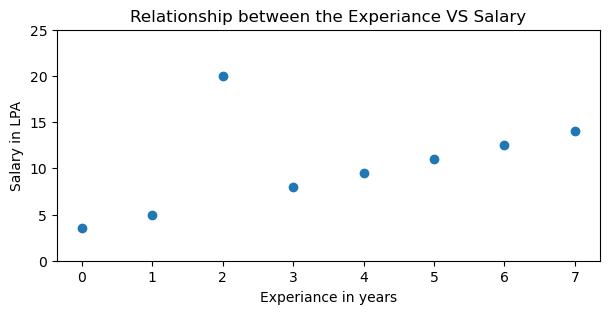

In [29]:
# Checking the relationship between Experience and Salary
plt.figure(figsize=(7,3))
plt.scatter(x = salary_details["Experiance"], y= salary_details["Salary"])
plt.xlabel("Experiance in years")
plt.ylabel("Salary in LPA")
plt.ylim(0,25)
plt.title("Relationship between the Experiance VS Salary")
print(salary_details.corr())
plt.show()

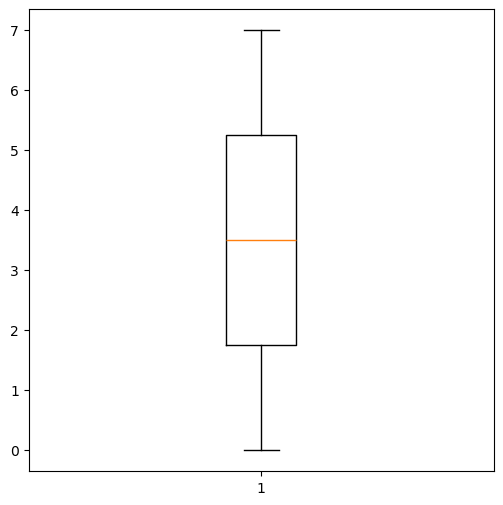

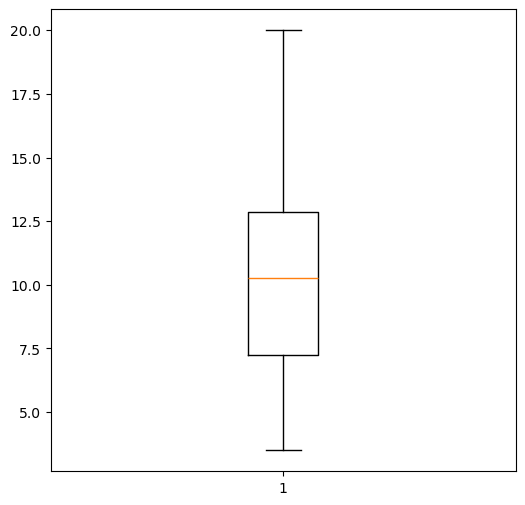

In [31]:
# Checking the distribution of the Experiance for detecting the outliers
plt.figure(figsize=(6,6))
plt.boxplot(x = salary_details["Experiance"])
plt.show()

# Checking the distribution of the Salary for detecting the outliers
plt.figure(figsize=(6,6))
plt.boxplot(x = salary_details["Salary"])
plt.show()

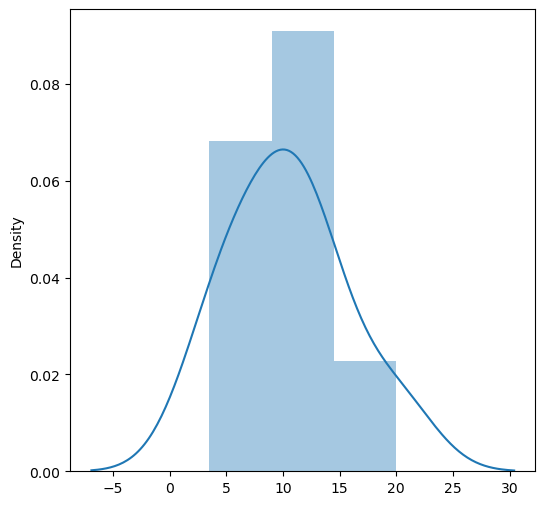

In [32]:
# Checking the distribution of the Salary for detecting the outliers
plt.figure(figsize=(6,6))
sns.distplot(x = salary_details["Salary"])
plt.show()

In [33]:
import sklearn as sk

In [34]:
salary_details

,Experiance,Salary
0,0,3.5
1,1,5.0
2,2,20.0
3,3,8.0
4,4,9.5
5,5,11.0
6,6,12.5
7,7,14.0


In [35]:
X = salary_details[["Experiance"]]
X

,Experiance
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7


In [36]:
y = salary_details["Salary"]
y

0     3.5
1     5.0
2    20.0
3     8.0
4     9.5
5    11.0
6    12.5
7    14.0
Name: Salary, dtype: float64

In [37]:
model = sk.linear_model.LinearRegression()
model.fit(X,y)

LinearRegression()

In [38]:
# Predict the salary of the person who is having 10 years of experiance:
salary_details

,Experiance,Salary
0,0,3.5
1,1,5.0
2,2,20.0
3,3,8.0
4,4,9.5
5,5,11.0
6,6,12.5
7,7,14.0


In [39]:
model.predict(np.array([[5]]))  # Last Prediction 11

array([11.96428571])

In [40]:
model.predict(np.array([[6]]))  # Last Prediction 13.5

array([12.98214286])

In [41]:
model.intercept_     # Intercept of the line

6.875

In [42]:
model.coef_          # Slope of the line

array([1.01785714])

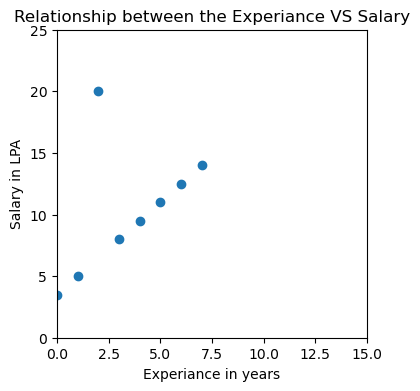

In [46]:
# Checking the relationship between Experience and Salary
plt.figure(figsize=(4,4))
plt.scatter(x = salary_details["Experiance"], y= salary_details["Salary"])
plt.xlim(0,15)
plt.ylim(0,25)
plt.xlabel("Experiance in years")
plt.ylabel("Salary in LPA")
plt.title("Relationship between the Experiance VS Salary")
plt.show()

In [47]:
salary_details.corr()

,Experiance,Salary
Experiance,1.000000,0.474555
Salary,0.474555,1.000000


In [48]:
r = 0.474555	

In [49]:
# Accuracy of the model
R_squared = r**2
R_squared

0.225202448025

In [50]:
salary_details[["Experiance"]]

,Experiance
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7


In [51]:
model.predict(salary_details[["Experiance"]])

array([ 6.875     ,  7.89285714,  8.91071429,  9.92857143, 10.94642857,
       11.96428571, 12.98214286, 14.        ])

In [52]:
pd.Series(model.predict(salary_details[["Experiance"]]))

0     6.875000
1     7.892857
2     8.910714
3     9.928571
4    10.946429
5    11.964286
6    12.982143
7    14.000000
dtype: float64

In [53]:
salary_details


,Experiance,Salary
0,0,3.5
1,1,5.0
2,2,20.0
3,3,8.0
4,4,9.5
5,5,11.0
6,6,12.5
7,7,14.0


In [54]:
salary_details["Predicted_salaries"] = pd.Series(model.predict(salary_details[["Experiance"]]))

In [55]:
salary_details

,Experiance,Salary,Predicted_salaries
0,0,3.5,6.875000
1,1,5.0,7.892857
2,2,20.0,8.910714
3,3,8.0,9.928571
4,4,9.5,10.946429
5,5,11.0,11.964286
6,6,12.5,12.982143
7,7,14.0,14.000000


In [61]:
print(model.intercept_)
print(model.coef_)

6.875
[1.01785714]


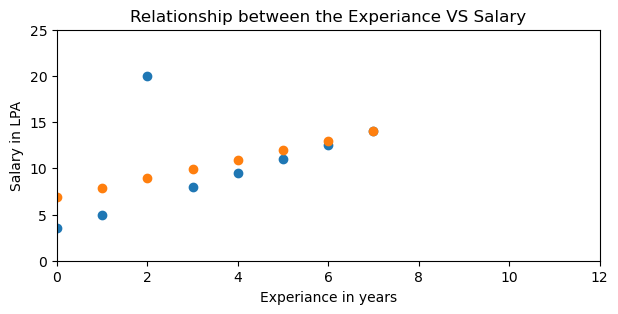

In [60]:
# Checking the relationship between Experience and Salary
plt.figure(figsize=(7,3))
plt.scatter(x = salary_details["Experiance"], y= salary_details["Salary"])
plt.scatter(x = salary_details["Experiance"], y= salary_details["Predicted_salaries"])
plt.xlim(0,12)
plt.ylim(0,25)
plt.xlabel("Experiance in years")
plt.ylabel("Salary in LPA")
plt.title("Relationship between the Experiance VS Salary")
plt.show()

In [56]:
Error = salary_details["Salary"] - salary_details["Predicted_salaries"]
salary_details["Error"] = Error
salary_details

,Experiance,Salary,Predicted_salaries,Error
0,0,3.5,6.875000,-3.375000
1,1,5.0,7.892857,-2.892857
2,2,20.0,8.910714,11.089286
3,3,8.0,9.928571,-1.928571
4,4,9.5,10.946429,-1.446429
5,5,11.0,11.964286,-0.964286
6,6,12.5,12.982143,-0.482143
7,7,14.0,14.000000,0.000000


In [33]:
salary_details

,Experiance,Salary,Predicted_salaries,Error
0,0,3.5,14.797368,-11.297368
1,1,4.5,13.878947,-9.378947
2,2,5.5,12.960526,-7.460526
3,1,45.0,13.878947,31.121053
4,4,7.5,11.123684,-3.623684
5,5,8.5,10.205263,-1.705263
6,6,9.5,9.286842,0.213158
7,7,10.5,8.368421,2.131579


In [62]:
# sk.metrics.accuracy_score(salary_details["Salary"],salary_details["Predicted_salaries"])